In [5]:
import pandas as pd
import numpy as np
import warnings
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.feature_selection import mutual_info_classif
from scipy.stats import chi2_contingency
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.model_selection import  cross_val_predict
from sklearn.metrics import classification_report
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.base import BaseEstimator, TransformerMixin

warnings.filterwarnings('ignore')

In [6]:
#Models of interest
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

In [7]:
df = pd.read_csv("Post_EDA_data.csv")
df.head()

,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,emp_length,home_ownership,...,tot_hi_cred_lim,total_bal_ex_mort,total_bc_limit,total_il_high_credit_limit,hardship_flag,debt_settlement_flag,y,Customer_history,issue_year,issue_month
0,12000.0,12000.0,12000.0,36 months,7.97,375.88,A,A5,10+ years,OWN,...,57180.0,30502.0,15500.0,26180.0,N,N,1,7762,2017,9
1,32000.0,32000.0,32000.0,36 months,11.99,1062.71,B,B5,10+ years,MORTGAGE,...,527034.0,63891.0,124200.0,20034.0,Y,N,1,4383,2017,9
2,40000.0,40000.0,40000.0,60 months,15.05,952.65,C,C4,9 years,MORTGAGE,...,367745.0,154261.0,64600.0,168145.0,N,N,1,5632,2017,9
3,16000.0,16000.0,16000.0,36 months,7.97,501.17,A,A5,5 years,RENT,...,125018.0,128572.0,3700.0,96918.0,N,N,1,6301,2017,9
4,33000.0,33000.0,33000.0,36 months,7.21,1022.12,A,A3,< 1 year,MORTGAGE,...,404510.0,48219.0,81700.0,73015.0,Y,N,0,4292,2017,9


In [8]:
df.shape

(2029952, 97)

In [9]:
#self.Q1_ saves the learned threshold from training so it can be consistently applied to new data.
class OutlierFlagger(BaseEstimator, TransformerMixin):
    def fit(self,X):
        #To keep track of the columns
        self.feature_names_in_ = list(X.columns)
        self.Q1 = X.quantile(0.25)
        self.Q3 = X.quantile(0.75)
        self.IQR = self.Q3 - self.Q1
        #Return the capsulated info obtained
        return self

    def transform(self,X):
        lower = self.Q1 -  1.5*self.IQR
        upper = self.Q3 +  1.5*self.IQR
        flags = ((X < lower) |(X>upper)).astype(int)
        #We keep the original feature and add a new column to capture outlier information, not replace it.

        flags.columns = [col + "_outlier" for col in X.columns]
        
        return pd.concat([X, flags], axis=1)
    
    def get_feature_names_out(self, input_features=None):
        if input_features is None:
            #Store the input features in a variable, then to a list
            input_features = self.feature_names_in_
        input_features = list(input_features)
        outlier_names = [col + "_outlier" for col in input_features]
        return np.array(input_features + outlier_names, dtype=object)

## Cross Validation

In [10]:
#Divide from X and y
X = df.drop("y", axis=1)
y= df["y"]

In [11]:
#Dropped after seeing it was data leakage
X.drop(["recoveries","collection_recovery_fee"],axis=1, inplace=True)
#recoveries is the money recovered after a loan has defaulted.
#collection_recovery_fee is the cost charged for collecting that recovered money.


In [12]:
leakage_cols = [
    "out_prncp",
    "out_prncp_inv",
    "total_rec_prncp",
    "total_rec_late_fee",
    "last_pymnt_amnt",
    "debt_settlement_flag",
    "total_pymnt",
    "total_pymnt_inv",
    "total_rec_int"
]
X.drop(leakage_cols,axis=1,inplace=True)

In [13]:
#Hardship flag removal since it indicates if the borrower is haviung trouble paying
X.drop("hardship_flag",axis=1,inplace=True)

In [14]:
#subsample a subset of the data
X_sub = X.sample(n=200000, random_state=42)
y_sub = y.loc[X_sub.index]

In [15]:
# train/temp split
X_train, X_temp, y_train, y_temp = train_test_split(
    X_sub, y_sub,
    test_size=0.30,
    random_state=42,
    stratify=y_sub
)

#validation/test split
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

'''
Ideally we end up with
70% train
15% validation
15% test
'''

'\nIdeally we end up with\n70% train\n15% validation\n15% test\n'

In [16]:
numerical_columns = X.select_dtypes(include="number", exclude=["category","object"]).columns
Cat_columns = X.select_dtypes(include=["object","category"]).columns

In [17]:
#Sample the numerical columns only from the training data
X_sample = X_train.sample(n=5000, random_state=42)
y_sample = y_train.loc[X_sample.index]

In [18]:
#Only numerical columns
X_num_sample = X_sample[numerical_columns]
X_num_sample.head()

,loan_amnt,funded_amnt,funded_amnt_inv,int_rate,installment,annual_inc,dti,delinq_2yrs,fico_range_low,fico_range_high,...,percent_bc_gt_75,pub_rec_bankruptcies,tax_liens,tot_hi_cred_lim,total_bal_ex_mort,total_bc_limit,total_il_high_credit_limit,Customer_history,issue_year,issue_month
1308177,5000.0,5000.0,5000.0,17.57,179.69,20000.0,35.29,0.0,735.0,739.0,...,33.3,0.0,0.0,45599.0,36151.0,6500.0,32599.0,3103,2015,3
690673,37600.0,37600.0,37600.0,7.21,1164.60,325000.0,12.62,1.0,770.0,774.0,...,5.9,0.0,0.0,540557.0,78845.0,184400.0,110052.0,7884,2018,10
568761,9000.0,9000.0,9000.0,10.08,290.75,33000.0,27.71,0.0,675.0,679.0,...,50.0,0.0,0.0,36000.0,24728.0,31000.0,0.0,5844,2018,7
1425531,28000.0,28000.0,27900.0,14.46,658.21,121400.0,5.07,0.0,755.0,759.0,...,28.6,0.0,0.0,926200.0,18207.0,30200.0,0.0,6453,2016,3
1588854,28000.0,28000.0,28000.0,22.45,780.52,110000.0,14.87,5.0,665.0,669.0,...,50.0,0.0,0.0,517611.0,92630.0,4500.0,118470.0,6664,2016,5


## PCA & t-nse

In [19]:
#Consruct the numerical pipeline and fit transform
num_only_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median", add_indicator=True)),
    ("scaler", StandardScaler())
])

X_num_processed = num_only_pipe.fit_transform(X_num_sample)

In [20]:
#Do PCA on the trimmed data
pca = PCA(n_components=30, random_state=42)
X_pca = pca.fit_transform(X_num_processed)

In [21]:
#Apply t-nse
tsne = TSNE(n_components=2, perplexity=30, random_state=42)
X_tsne = tsne.fit_transform(X_pca)

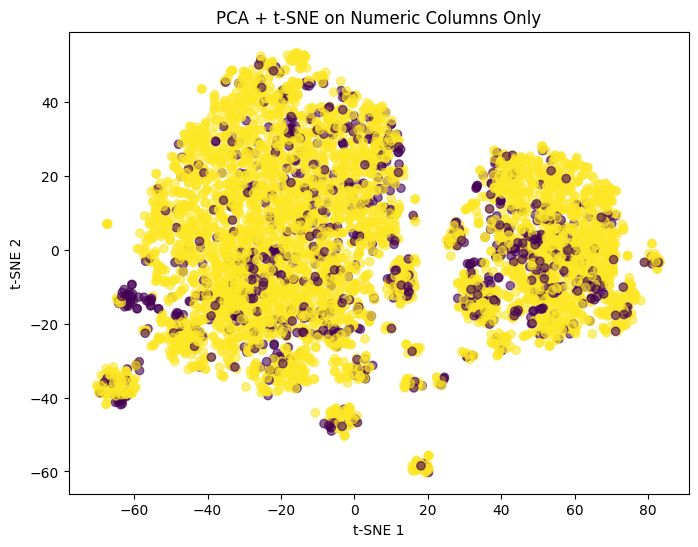

In [22]:
plt.figure(figsize=(8, 6))
plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=y_sample, alpha=0.6)
plt.title("PCA + t-SNE on Numeric Columns Only")
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.show()

## ---------------------------

## Pipeline creation & post-transformation evaluation & Univariate variable selection

In [23]:
#Categorical pipeline
cat_pip = Pipeline([
    ("imputer",SimpleImputer(strategy='most_frequent', add_indicator=True)),
    ("ohe", OneHotEncoder(drop="first", handle_unknown="ignore", sparse_output=False)),

])

#Numerical Pipeline
numerical_pip = Pipeline([
    ('imputer', SimpleImputer(strategy='median', add_indicator=True)),
    ("scaled",StandardScaler())
])

#COlumnTransformer
preprocessing = ColumnTransformer(
    transformers=[
        ('cat',cat_pip,Cat_columns),
        ('num',numerical_pip,numerical_columns),
    ], remainder="passthrough"
)



We impute so the model has a usable value and can still learn from that feature, and we add a missing indicator because the fact that the value was missing may itself carry predictive information. Doing both lets the model use both the feature’s information and the missingness signal.

In [24]:
# Fit on train
X_train_transformed = preprocessing.fit_transform(X_train)
X_val_transformed = preprocessing.transform(X_val)

# Feature names
feature_names = preprocessing.get_feature_names_out()

# Convert to DataFrames
X_train_preprocessed = pd.DataFrame(
    X_train_transformed,
    columns=feature_names,
    index=X_train.index
)

X_val_preprocessed = pd.DataFrame(
    X_val_transformed,
    columns=feature_names,
    index=X_val.index
)

In [25]:
X_train_preprocessed

,cat__term_60 months,cat__grade_B,cat__grade_C,cat__grade_D,cat__grade_E,cat__grade_F,cat__grade_G,cat__sub_grade_A2,cat__sub_grade_A3,cat__sub_grade_A4,...,num__missingindicator_total_cu_tl,num__missingindicator_inq_last_12m,num__missingindicator_avg_cur_bal,num__missingindicator_bc_open_to_buy,num__missingindicator_bc_util,num__missingindicator_mo_sin_old_il_acct,num__missingindicator_mths_since_recent_bc,num__missingindicator_mths_since_recent_inq,num__missingindicator_num_tl_120dpd_2m,num__missingindicator_percent_bc_gt_75
36890,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,-0.673942,-0.673942,-0.005976,-0.10718,-0.109875,-0.179775,-0.103788,-0.353981,-0.203345,-0.108266
753927,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,1.483807,1.483807,-0.005976,-0.10718,-0.109875,-0.179775,-0.103788,-0.353981,-0.203345,-0.108266
152768,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,-0.673942,-0.673942,-0.005976,-0.10718,-0.109875,5.562517,-0.103788,-0.353981,-0.203345,-0.108266
1695042,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,-0.673942,-0.673942,-0.005976,-0.10718,-0.109875,-0.179775,-0.103788,-0.353981,-0.203345,-0.108266
707314,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,-0.673942,-0.673942,-0.005976,-0.10718,-0.109875,-0.179775,-0.103788,-0.353981,-0.203345,-0.108266
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1872710,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,-0.673942,-0.673942,-0.005976,-0.10718,-0.109875,-0.179775,-0.103788,-0.353981,-0.203345,-0.108266
710340,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,-0.673942,-0.673942,-0.005976,-0.10718,-0.109875,5.562517,-0.103788,2.825012,-0.203345,-0.108266
322154,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,-0.673942,-0.673942,-0.005976,-0.10718,-0.109875,-0.179775,-0.103788,-0.353981,-0.203345,-0.108266
283075,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,-0.673942,-0.673942,-0.005976,-0.10718,-0.109875,-0.179775,-0.103788,-0.353981,-0.203345,-0.108266


In [26]:
X_train_preprocessed.shape

(140000, 219)

In [27]:
numerical_columns_preprocessed = [col for col in X_train_preprocessed.columns if col not in ["y"] and not col.startswith("cat")]
Categorical_columns_preprocessed = [col for col in X_train_preprocessed.columns if col not in ["y"] and  col.startswith("cat")]

In [28]:
X_train_preprocessed[numerical_columns_preprocessed].head()

,num__loan_amnt,num__funded_amnt,num__funded_amnt_inv,num__int_rate,num__installment,num__annual_inc,num__dti,num__delinq_2yrs,num__fico_range_low,num__fico_range_high,...,num__missingindicator_total_cu_tl,num__missingindicator_inq_last_12m,num__missingindicator_avg_cur_bal,num__missingindicator_bc_open_to_buy,num__missingindicator_bc_util,num__missingindicator_mo_sin_old_il_acct,num__missingindicator_mths_since_recent_bc,num__missingindicator_mths_since_recent_inq,num__missingindicator_num_tl_120dpd_2m,num__missingindicator_percent_bc_gt_75
36890,-0.023412,-0.023405,-0.022874,0.425279,0.265934,0.847716,-0.604593,1.884149,-0.258983,-0.258982,...,-0.673942,-0.673942,-0.005976,-0.10718,-0.109875,-0.179775,-0.103788,-0.353981,-0.203345,-0.108266
753927,-1.100063,-1.100056,-1.099751,-1.230913,-1.094536,0.641000,-1.146042,-0.352865,-1.012517,-1.012499,...,1.483807,1.483807,-0.005976,-0.10718,-0.109875,-0.179775,-0.103788,-0.353981,-0.203345,-0.108266
152768,0.514914,0.514920,0.515565,0.624597,0.140399,-0.737104,-0.694363,-0.352865,0.193137,0.193128,...,-0.673942,-0.673942,-0.005976,-0.10718,-0.109875,5.562517,-0.103788,-0.353981,-0.203345,-0.108266
1695042,0.428782,0.428788,0.429414,1.029398,0.143633,0.158664,-0.520477,-0.352865,-1.012517,-1.012499,...,-0.673942,-0.673942,-0.005976,-0.10718,-0.109875,-0.179775,-0.103788,-0.353981,-0.203345,-0.108266
707314,0.299584,0.299590,0.294805,0.649255,-0.036211,-0.461483,-0.373452,-0.352865,0.946671,0.946645,...,-0.673942,-0.673942,-0.005976,-0.10718,-0.109875,-0.179775,-0.103788,-0.353981,-0.203345,-0.108266


Block of code below assesses the multicollinearity between 2 numerical independent variables. If it is above a certain threshold we remove the one with less mutual information

In [29]:
#Correlation between numerical columns selection
threshold = 0.8
corr_matrix = X_train_preprocessed[numerical_columns_preprocessed].corr(numeric_only=True).abs()

mask = np.triu(np.ones_like(corr_matrix), k=1).astype(bool)
upper = corr_matrix.where(mask)

#Use the set to not collect duplicates
columns_to_drop = set()

for col in upper.columns:
    for row in upper.index:
        if upper.loc[row,col] > threshold and pd.notna(upper.loc[row, col]):
            #mutual info needs to be 2d
            mi_row = mutual_info_classif(X_train_preprocessed[[row]],y_train.values)
            mi_col = mutual_info_classif(X_train_preprocessed[[col]],y_train.values)
            #reminder larger values means stronger association
            if mi_row[0] >= mi_col[0]:
                columns_to_drop.add(col)
            else:
                columns_to_drop.add(row)

X_train_reduced = X_train_preprocessed.drop(columns=list(columns_to_drop), axis=1)

In [30]:
len(columns_to_drop)

38

In [31]:
#Look at the remaining columns
X_train_reduced.shape[1]

181

In [32]:
def cramers_V(x,y):
    '''
    Here we calculate the Cramer's V to asses the strength of association between 2 nominal variables
    '''
    table =pd.crosstab(x,y)
    #Extract only the chi-square statistics
    chi2=chi2_contingency(table)[0]
    n = table.sum().sum()
    r,k = table.shape
    return np.sqrt(chi2 / (n*(min(r,k) -1)))

In [33]:
#Here we test something similar as the above w.r.t numerical. We assess
#The categorical variables strength, and if above a specified threshold
#We remove the one with less mutual information
cat_cols = Categorical_columns_preprocessed  
threshold = 0.8

to_drop = set()

for i in range(len(cat_cols)):
    for j in range(i + 1, len(cat_cols)):
        col1 = cat_cols[i]
        col2 = cat_cols[j]
        
        v = cramers_V(X_train_preprocessed[col1], X_train_preprocessed[col2])
        
        if v > threshold:
            # compare usefulness with target using mutual info
            mi1 = mutual_info_classif(X_train_preprocessed[[col1]], y_train.values, discrete_features=True)
            mi2 = mutual_info_classif(X_train_preprocessed[[col2]], y_train.values, discrete_features=True)
            
            if mi1[0] >= mi2[0]:
                to_drop.add(col2)
            else:
                to_drop.add(col1)

In [34]:
X_train_reduced = X_train_reduced.drop(columns=list(to_drop), axis=1)

In [35]:
X_train_reduced.shape[1]
#Looks like we will keep every single categorical variable

181

## Variable Selection via tree-based model

In [36]:
from sklearn.feature_selection import SelectFromModel

In [37]:
rf = RandomForestClassifier(n_estimators=100,random_state=42)
rf.fit(X_train_reduced,y_train)


#Select the feature with more importance above a threshold
#Prefit is to tell that there will be a prefit model to be presented
#In here we use it for a quick approximation a baseline of sorts
model_selector = SelectFromModel(rf,prefit=True, threshold='mean')
X_train_selected = model_selector.transform(X_train_reduced)
print(f"Original feature number: {X_train_reduced.shape[1]}, Selected feature number: {X_train_selected.shape[1]}")

Original feature number: 181, Selected feature number: 37


In [38]:
selected_cols = X_train_reduced.columns[model_selector.get_support()]

In [39]:
X_train_selected_df = pd.DataFrame(
    X_train_selected,
    columns=selected_cols,
    index=X_train_reduced.index
)

In [40]:
X_train_selected_df.columns

Index(['cat__term_60 months', 'num__int_rate', 'num__installment',
       'num__annual_inc', 'num__dti', 'num__fico_range_low',
       'num__mths_since_last_delinq', 'num__revol_bal', 'num__revol_util',
       'num__total_acc', 'num__last_fico_range_low', 'num__open_act_il',
       'num__mths_since_rcnt_il', 'num__total_bal_il', 'num__il_util',
       'num__open_rv_24m', 'num__max_bal_bc', 'num__all_util',
       'num__total_rev_hi_lim', 'num__inq_last_12m',
       'num__acc_open_past_24mths', 'num__avg_cur_bal', 'num__bc_open_to_buy',
       'num__mo_sin_old_il_acct', 'num__mo_sin_rcnt_rev_tl_op',
       'num__mo_sin_rcnt_tl', 'num__mort_acc', 'num__mths_since_recent_bc',
       'num__mths_since_recent_inq', 'num__num_bc_tl', 'num__num_il_tl',
       'num__num_rev_tl_bal_gt_0', 'num__num_tl_op_past_12m',
       'num__pct_tl_nvr_dlq', 'num__percent_bc_gt_75', 'num__Customer_history',
       'num__issue_month'],
      dtype='object')

In [41]:
#We have to recalculate post varaible selection
numerical_columns_preprocessed = [col for col in X_train_selected_df.columns if col not in ["y"] and not col.startswith("cat")]
Categorical_columns_preprocessed = [col for col in X_train_selected_df.columns if col not in ["y"] and  col.startswith("cat")]

In [42]:
#Quickly re-establish the pipeline with our new variables in mind

#Categorical pipeline
cat_pip = Pipeline([
    ("imputer",SimpleImputer(strategy='most_frequent', add_indicator=True)),
    ("ohe", OneHotEncoder(drop="first", handle_unknown="ignore", sparse_output=False)),

])

#Numerical Pipeline
numerical_pip = Pipeline([
    ('imputer', SimpleImputer(strategy='median', add_indicator=True)),
    ("scaled",StandardScaler())
])

#ColumnTransformer
preprocessing = ColumnTransformer(
    transformers=[
        ('cat',cat_pip,Categorical_columns_preprocessed),
        ('num',numerical_pip,numerical_columns_preprocessed),
    ], remainder="passthrough"
)

In [43]:
model = Pipeline([
    ("prep", preprocessing),
    ("Model",LogisticRegression())
])

In [44]:
cv = StratifiedKFold(n_splits=4, shuffle=True, random_state=42)

In [45]:
#Here we will use the f1 scoring metric since our dependent variable is unbalanced
scores = cross_val_score(model, X_train_selected_df, y_train, cv=cv, scoring='f1', n_jobs=-1)
print(scores.mean())

0.9460347524668999


In [46]:
#Quick more in depth check of the quick example
y_pred = cross_val_predict(model, X_train_selected_df, y_train, cv=cv, n_jobs=-1)

print(classification_report(y_train, y_pred))

              precision    recall  f1-score   support

           0       0.78      0.59      0.67     22504
           1       0.93      0.97      0.95    117496

    accuracy                           0.91    140000
   macro avg       0.85      0.78      0.81    140000
weighted avg       0.90      0.91      0.90    140000



* This may be variables that mainly benefit the tree based models or logistic regression and it is just a start instead of treating this subset as a definite set

## Model selection

In [47]:
from sklearn.metrics import roc_curve, roc_auc_score

Here is the list of models, that are a candidate pool of models
* (FFN) Feed forward Nueral Network
* Logistic regression
* Xg Boost
* random forest

In [126]:
def model_summary(fitted_model, X_val,y_val,model_name,reverse_dv:False):
    if reverse_dv:
        #Predicted probabilities for DV of 1
        y_probs = fitted_model.predict_proba(X_val)[:,0]
        y_pred = fitted_model.predict(X_val)

        class_report = classification_report(y_val,y_pred)
        # ROC values
        fpr, tpr, thresholds = roc_curve(1-y_val, y_probs)

        # AUC
        auc = roc_auc_score(1-y_val, y_probs)

        plt.plot(fpr, tpr, label=f"AUC = {auc:.3f}")
        #Baseline
        plt.plot([0, 1], [0, 1], linestyle='--') 
        plt.xlabel("False Positive Rate")
        plt.ylabel("True Positive Rate")
        plt.title("ROC Curve of DV=0")
        plt.legend()
        plt.show()

        print(class_report)
        print(f"current model auc:{auc}")
    else:
        #Predicted probabilities for DV of 1
        y_probs = fitted_model.predict_proba(X_val)[:,1]
        y_pred = fitted_model.predict(X_val)

        class_report = classification_report(y_val,y_pred)
        # ROC values
        fpr, tpr, thresholds = roc_curve(y_val, y_probs)

        # AUC
        auc = roc_auc_score(y_val, y_probs)

        plt.plot(fpr, tpr, label=f"AUC = {auc:.3f}")
        #Baseline
        plt.plot([0, 1], [0, 1], linestyle='--') 
        plt.xlabel("False Positive Rate")
        plt.ylabel("True Positive Rate")
        plt.title("ROC Curve of DV=1")
        plt.legend()
        plt.show()

        


        print(class_report)
        print(f"current model auc:{auc:3f}")
        print(f"current model name:{model_name}")

In [57]:
numerical_columns_train = X_train.select_dtypes(include="number", exclude=["category","object"]).columns
Cat_columns_train = X_train.select_dtypes(include=["object","category"]).columns

In [58]:
#Pipeline that is buuilt specifically for the baseline model

#Categorical pipeline
cat_pip = Pipeline([
    ("imputer",SimpleImputer(strategy='most_frequent', add_indicator=True)),
    ("ohe", OneHotEncoder(drop="first", handle_unknown="ignore", sparse_output=False)),

])

#Numerical Pipeline
numerical_pip = Pipeline([
    ('imputer', SimpleImputer(strategy='median', add_indicator=True)),
    ("scaled",StandardScaler())
])

#ColumnTransformer
preprocessing = ColumnTransformer(
    transformers=[
        ('cat',cat_pip,Cat_columns_train),
        ('num',numerical_pip,numerical_columns_train),
    ], remainder="passthrough"
)

In [59]:
baseline_pipeline = Pipeline([
    ("process",preprocessing),
    ("selector",SelectFromModel(
        RandomForestClassifier(n_estimators=1000,random_state=42), threshold='mean'
    )),
    ("model", LogisticRegression())
])

In [60]:
baseline_pipeline.fit(X_train,y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('process', ...), ('selector', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different trans

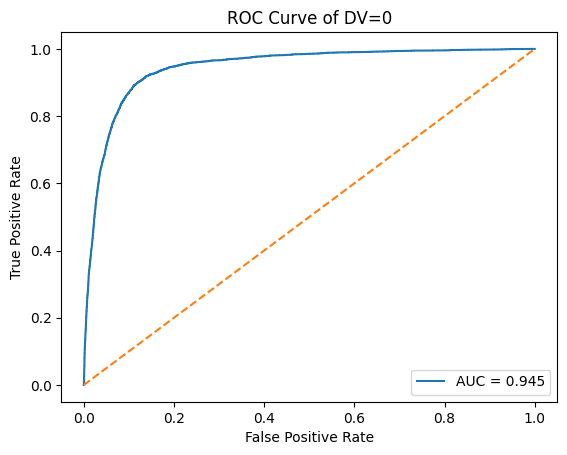

              precision    recall  f1-score   support

           0       0.75      0.68      0.71      4822
           1       0.94      0.96      0.95     25178

    accuracy                           0.91     30000
   macro avg       0.84      0.82      0.83     30000
weighted avg       0.91      0.91      0.91     30000

current model auc:0.9447070330833021


In [98]:
model_summary(baseline_pipeline,X_val,y_val,model_name="Logistic Regression", reverse_dv=True)

In [123]:
def Youden_threshold(fitted_model, X_val,y_val, reverse_dv=False):
    if reverse_dv:
        y_probs = fitted_model.predict_proba(X_val)[:,0]
        fpr,tpr, thresholds = roc_curve(1-y_val,y_probs)
    else:
        y_probs = fitted_model.predict_proba(X_val)[:,1]
        fpr,tpr, thresholds = roc_curve(y_val,y_probs)

    j_scores = tpr-fpr
    #argmax returns the index of the largest value in a list or array.
    best_idx = np.argmax(j_scores)
    j_threshold = thresholds[best_idx]

    print(f"Youden threshold: {j_threshold}")
    if reverse_dv:
        y_pred_changed = (y_probs >= j_threshold).astype(int)
        y_pred_changed = 1 - y_pred_changed
    else:
        y_pred_changed = (y_probs >= j_threshold).astype(int)
    print("Classification report with threshold")
    print(classification_report(y_val,y_pred_changed))


In [111]:
from sklearn.metrics import f1_score

In [114]:
def f1_threshold(fitted_model, X_val,y_val, reverse_dv=False):

    y_probs = fitted_model.predict_proba(X_val)[:,1]

    thresholds = np.linspace(0,1,100)
    f1_scores = []

    for t in thresholds:
        y_pred = (y_probs >= t).astype(int)
        if reverse_dv:
            score = f1_score(y_val,y_pred,pos_label=0)
        else:
            score = f1_score(y_val,y_pred)
        f1_scores.append(score)


    best_idx = np.argmax(f1_scores)
    optimal_threshold = thresholds[best_idx]

    print(f"F1 optimal threshold: {optimal_threshold}")
    y_pred_optimal = (y_probs >= optimal_threshold).astype(int)
    print("Classification report with threshold")
    print(classification_report(y_val,y_pred_optimal))


In [125]:
Youden_threshold(baseline_pipeline,X_val,y_val,reverse_dv=False)

Youden threshold: 0.8511350363753084
Classification report with threshold
              precision    recall  f1-score   support

           0       0.59      0.90      0.71      4822
           1       0.98      0.88      0.93     25178

    accuracy                           0.88     30000
   macro avg       0.79      0.89      0.82     30000
weighted avg       0.92      0.88      0.89     30000



In [115]:
f1_threshold(baseline_pipeline, X_val,y_val, reverse_dv=True)

F1 optimal threshold: 0.686868686868687
Classification report with threshold
              precision    recall  f1-score   support

           0       0.69      0.80      0.74      4822
           1       0.96      0.93      0.94     25178

    accuracy                           0.91     30000
   macro avg       0.82      0.86      0.84     30000
weighted avg       0.92      0.91      0.91     30000



In [ ]:
#%pip install skorch


   -------------------- ------------------- 1/2 [skorch]
   -------------------- ------------------- 1/2 [skorch]
   -------------------- ------------------- 1/2 [skorch]
   -------------------- ------------------- 1/2 [skorch]
   -------------------- ------------------- 1/2 [skorch]
   -------------------- ------------------- 1/2 [skorch]
   -------------------- ------------------- 1/2 [skorch]
   ---------------------------------------- 2/2 [skorch]

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [131]:
import torch 
import torch.nn as nn
from skorch import NeuralNetClassifier

In [ ]:
#Create a custom made NN(currently it's simple ill play around a bit more later). I plan to develop the batch,gradient descent more manually eventually
class NN_test(nn.Module):
    def __init__(self,num_features):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(num_features,32),
            nn.Sigmoid(),
            nn.Linear(32,64),
            nn.Sigmoid(),
            nn.Linear(64,2)
        )
    
    def forward(self,X):
        return self.net(X)

        

In [148]:
NN_classifier = NeuralNetClassifier(
    NN_test,
    module__num_features=preprocessing.fit_transform(X_train).shape[1],
    max_epochs=20,
    lr=0.01,
    batch_size=32,
    criterion=nn.CrossEntropyLoss,
    verbose=0
)

In [149]:
from sklearn.preprocessing import FunctionTransformer

to_dense = FunctionTransformer(
    lambda x: x.toarray() if hasattr(x, "toarray") else x
)

to_float = FunctionTransformer(
    lambda x: x.astype(np.float32)
)

In [ ]:
#test pipeline basically to just adjust to fit into sklearn pipeline
pipe = Pipeline([
    ("process", preprocessing),
    ("to_dense", to_dense),
    ("to_float", to_float),
    ("model", NN_classifier)
])



pipe.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('process', ...), ('to_dense', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different trans

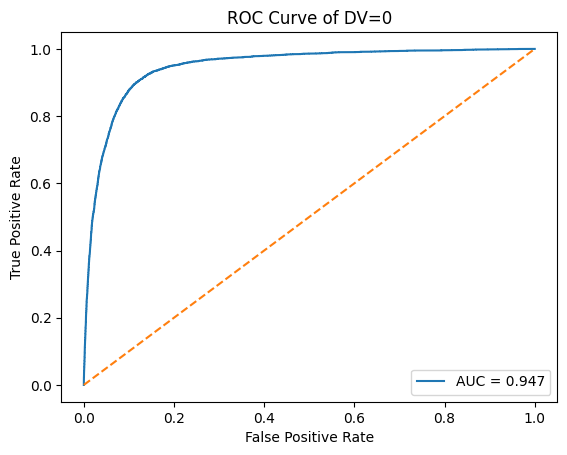

              precision    recall  f1-score   support

           0       0.74      0.72      0.73      4822
           1       0.95      0.95      0.95     25178

    accuracy                           0.91     30000
   macro avg       0.84      0.83      0.84     30000
weighted avg       0.91      0.91      0.91     30000

current model auc:0.9474274439322592


In [151]:
model_summary(pipe, X_val, y_val, "Neural Net",reverse_dv=True)

In [153]:
models_of_interest =[
("Logistic Regression",LogisticRegression(max_iter=1000)),
("Random Forest",RandomForestClassifier(n_estimators=200,random_state=42)),
("XG Boost",XGBClassifier())
]

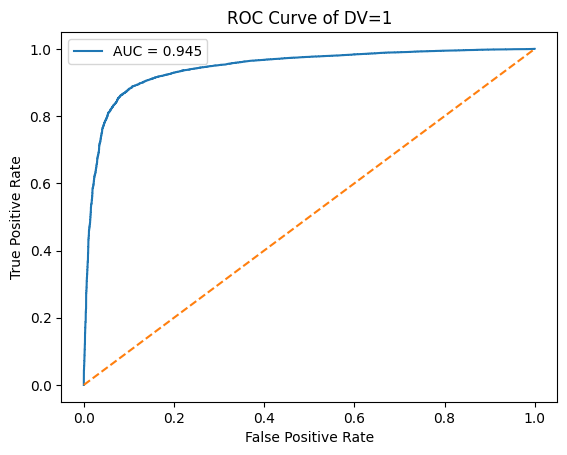

              precision    recall  f1-score   support

           0       0.75      0.68      0.71      4822
           1       0.94      0.96      0.95     25178

    accuracy                           0.91     30000
   macro avg       0.84      0.82      0.83     30000
weighted avg       0.91      0.91      0.91     30000

current model auc:0.944707
current model name:Logistic Regression


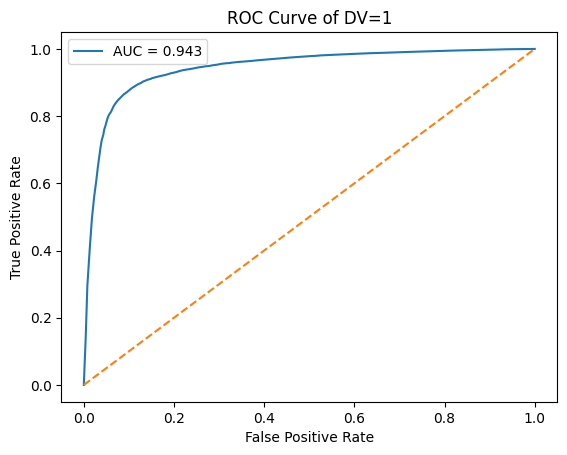

              precision    recall  f1-score   support

           0       0.73      0.72      0.73      4822
           1       0.95      0.95      0.95     25178

    accuracy                           0.91     30000
   macro avg       0.84      0.84      0.84     30000
weighted avg       0.91      0.91      0.91     30000

current model auc:0.942905
current model name:Random Forest


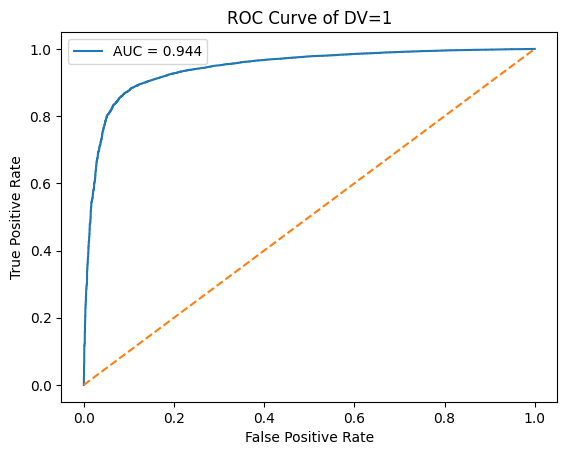

              precision    recall  f1-score   support

           0       0.73      0.71      0.72      4822
           1       0.94      0.95      0.95     25178

    accuracy                           0.91     30000
   macro avg       0.84      0.83      0.83     30000
weighted avg       0.91      0.91      0.91     30000

current model auc:0.944251
current model name:XG Boost


In [155]:
for model_name,model in models_of_interest:

    baseline_pipeline = Pipeline([
        ("process",preprocessing),
        ("selector",SelectFromModel(
            RandomForestClassifier(n_estimators=1000,random_state=42), threshold='mean'
        )),
        ("model", model)
    ])

    baseline_pipeline.fit(X_train,y_train)
    model_summary(baseline_pipeline,X_val,y_val,model_name=model_name,reverse_dv=False)
